In [1]:
import os
import tqdm
import time
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.optim.lr_scheduler import _LRScheduler
import torch.optim as optim
from torch.utils import data as torch_data

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
from sklearn.metrics import classification_report

import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import copy

import random

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  device = torch.device("mps")
else:
  device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


# DatacenterDataset code

In [4]:
class DatacenterDataset(Dataset):
    def __init__(self, src, trg, class_names):
        self.src = torch.tensor(src, dtype=torch.float32)
        self.trg = torch.tensor(trg, dtype=torch.long)
        self.class_names = class_names

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.trg[idx]

In [5]:
class DatacenterTwoTowerDataset(torch_data.Dataset):
    def __init__(self, X_gpu, X_cpu, y, class_names):
        self.X_gpu = torch.tensor(X_gpu, dtype=torch.float32)
        self.X_cpu = torch.tensor(X_cpu, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.class_names = class_names

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_gpu[idx], self.X_cpu[idx], self.y[idx]

# Load ML Data


In [6]:
def set_seed(seed=2022):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(2022)

In [7]:
max_workers = 0
batch_size = 32

In [8]:
def split_data_combined_dataset(npz_path):

  ml_data = np.load(npz_path)
  X, y, model = ml_data["X"], ml_data["y"], ml_data["model"]

  print(X.shape, y.shape, model.shape)

  class_map = (
      pd.DataFrame({"y": y, "model": model})
      .drop_duplicates()
      .sort_values("y")
  )

  assert class_map["y"].is_unique
  assert class_map["model"].is_unique
  assert np.array_equal(class_map["y"].values, np.arange(len(class_map)))

  class_names = class_map["model"].values

  # First split: train+val vs test
  sss1 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=37
  )

  for train_val_idx, test_idx in sss1.split(X, y):
      X_train_val, X_test = X[train_val_idx], X[test_idx]
      y_train_val, y_test = y[train_val_idx], y[test_idx]

  # Second split: train vs validation
  sss2 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=38
  )

  for train_idx, val_idx in sss2.split(X_train_val, y_train_val):
      X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
      y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

  print("Train:", X_train.shape, y_train.shape)
  print("Val:  ", X_val.shape, y_val.shape)
  print("Test: ", X_test.shape, y_test.shape)

  n_classes = len(np.unique(y_train))

  # Standardize using train only
  scaler = StandardScaler()

  X_train = scaler.fit_transform(
      X_train.reshape(-1, X_train.shape[-1])
  ).reshape(X_train.shape)

  X_val = scaler.transform(
      X_val.reshape(-1, X_val.shape[-1])
  ).reshape(X_val.shape)

  X_test = scaler.transform(
      X_test.reshape(-1, X_test.shape[-1])
  ).reshape(X_test.shape)

  # Build datasets
  dset_train = DatacenterDataset(X_train, y_train, class_names)
  dset_val = DatacenterDataset(X_val, y_val, class_names)
  dset_test = DatacenterDataset(X_test, y_test, class_names)

  train_dl_combined = torch_data.DataLoader(
      dset_train,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=True
  )

  val_dl_combined = torch_data.DataLoader(
      dset_val,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  test_dl_combined = torch_data.DataLoader(
      dset_test,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )
  return train_dl_combined, val_dl_combined, test_dl_combined

In [9]:
def split_data_separate_dataset(npz_path):

  ml_data = np.load(npz_path)
  X_gpu = ml_data["X_gpu"]
  X_cpu = ml_data["X_cpu"]
  y = ml_data["y"]
  model = ml_data["model"]

  print(X_gpu.shape, X_cpu.shape, y.shape, model.shape)

  class_map = (
      pd.DataFrame({"y": y, "model": model})
      .drop_duplicates()
      .sort_values("y")
  )

  assert class_map["y"].is_unique
  assert class_map["model"].is_unique
  assert np.array_equal(class_map["y"].values, np.arange(len(class_map)))

  class_names = class_map["model"].values

  # First split: train+val vs test
  sss1 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=37
  )

  for train_val_idx, test_idx in sss1.split(X_gpu, y):
      X_gpu_train_val, X_gpu_test = X_gpu[train_val_idx], X_gpu[test_idx]
      X_cpu_train_val, X_cpu_test = X_cpu[train_val_idx], X_cpu[test_idx]
      y_train_val, y_test = y[train_val_idx], y[test_idx]
      model_train_val, model_test = model[train_val_idx], model[test_idx]

  # Second split: train vs validation
  sss2 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=38
  )

  for train_idx, val_idx in sss2.split(X_gpu_train_val, y_train_val):
      X_gpu_train, X_gpu_val = X_gpu_train_val[train_idx], X_gpu_train_val[val_idx]
      X_cpu_train, X_cpu_val = X_cpu_train_val[train_idx], X_cpu_train_val[val_idx]
      y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]
      model_train, model_val = model_train_val[train_idx], model_train_val[val_idx]

  print("GPU train:", X_gpu_train.shape)
  print("CPU train:", X_cpu_train.shape)
  print("y train:  ", y_train.shape)

  print("GPU val:", X_gpu_val.shape)
  print("CPU val:", X_cpu_val.shape)
  print("y val:  ", y_val.shape)

  print("GPU test:", X_gpu_test.shape)
  print("CPU test:", X_cpu_test.shape)
  print("y test:  ", y_test.shape)

  n_classes = len(np.unique(y_train))

  gpu_scaler = StandardScaler()
  cpu_scaler = StandardScaler()

  X_gpu_train = gpu_scaler.fit_transform(
      X_gpu_train.reshape(-1, X_gpu_train.shape[-1])
  ).reshape(X_gpu_train.shape)

  X_gpu_val = gpu_scaler.transform(
      X_gpu_val.reshape(-1, X_gpu_val.shape[-1])
  ).reshape(X_gpu_val.shape)

  X_gpu_test = gpu_scaler.transform(
      X_gpu_test.reshape(-1, X_gpu_test.shape[-1])
  ).reshape(X_gpu_test.shape)


  X_cpu_train = cpu_scaler.fit_transform(
      X_cpu_train.reshape(-1, X_cpu_train.shape[-1])
  ).reshape(X_cpu_train.shape)

  X_cpu_val = cpu_scaler.transform(
      X_cpu_val.reshape(-1, X_cpu_val.shape[-1])
  ).reshape(X_cpu_val.shape)

  X_cpu_test = cpu_scaler.transform(
      X_cpu_test.reshape(-1, X_cpu_test.shape[-1])
  ).reshape(X_cpu_test.shape)

  dset_train = DatacenterTwoTowerDataset(X_gpu_train, X_cpu_train, y_train, class_names)
  dset_val = DatacenterTwoTowerDataset(X_gpu_val, X_cpu_val, y_val, class_names)
  dset_test = DatacenterTwoTowerDataset(X_gpu_test, X_cpu_test, y_test, class_names)

  train_dl_sep = torch_data.DataLoader(
      dset_train,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=True
  )

  val_dl_sep = torch_data.DataLoader(
      dset_val,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  test_dl_sep = torch_data.DataLoader(
      dset_test,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  return train_dl_sep, val_dl_sep, test_dl_sep

In [10]:
data_directory_path_combined = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/COMBINED"
data_directory_path_separate = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/SEPARATE"

combined_datasets = []
separated_datasets = []

for _file in os.listdir(data_directory_path_combined):
  if not _file.endswith(".npz"):
    continue
  _filepath = os.path.join(data_directory_path_combined, _file)
  train_dl_combined, val_dl_combined, test_dl_combined = split_data_combined_dataset(_filepath)
  combined_datasets.append({"name": _file, "train_dl": train_dl_combined, "val_dl": val_dl_combined, "test_dl": test_dl_combined})

for _file in os.listdir(data_directory_path_separate):
  if not _file.endswith(".npz"):
    continue
  _filepath = os.path.join(data_directory_path_separate, _file)
  train_dl_separate, val_dl_separate, test_dl_separate = split_data_separate_dataset(_filepath)
  separated_datasets.append({"name": _file, "train_dl": train_dl_separate, "val_dl": val_dl_separate, "test_dl": test_dl_separate})



(18238, 540, 15) (18238,) (18238,)
Train: (11672, 540, 15) (11672,)
Val:   (2918, 540, 15) (2918,)
Test:  (3648, 540, 15) (3648,)
(17767, 540, 15) (17767,) (17767,)
Train: (11370, 540, 15) (11370,)
Val:   (2843, 540, 15) (2843,)
Test:  (3554, 540, 15) (3554,)
(17728, 540, 15) (17728,) (17728,)
Train: (11345, 540, 15) (11345,)
Val:   (2837, 540, 15) (2837,)
Test:  (3546, 540, 15) (3546,)
(17725, 540, 15) (17725,) (17725,)
Train: (11344, 540, 15) (11344,)
Val:   (2836, 540, 15) (2836,)
Test:  (3545, 540, 15) (3545,)
(17741, 540, 15) (17741,) (17741,)
Train: (11353, 540, 15) (11353,)
Val:   (2839, 540, 15) (2839,)
Test:  (3549, 540, 15) (3549,)
(17724, 540, 15) (17724,) (17724,)
Train: (11343, 540, 15) (11343,)
Val:   (2836, 540, 15) (2836,)
Test:  (3545, 540, 15) (3545,)
(17733, 540, 15) (17733,) (17733,)
Train: (11348, 540, 15) (11348,)
Val:   (2838, 540, 15) (2838,)
Test:  (3547, 540, 15) (3547,)
(18238, 540, 7) (18238, 7, 8) (18238,) (18238,)
GPU train: (11672, 540, 7)
CPU train: (116

In [11]:
class_names_combined = test_dl_combined.dataset.class_names
print(class_names_combined)

['U3-128' 'U3-32' 'U3-64' 'U4-128' 'U4-32' 'U4-64' 'U5-128' 'U5-32'
 'U5-64' 'bert-base-uncased' 'conv' 'dimenet' 'distilbert-base-uncased'
 'inception3' 'inception4' 'pna' 'resnet101' 'resnet101_v2' 'resnet152'
 'resnet152_v2' 'resnet50' 'resnet50_v1.5' 'schnet' 'vgg11' 'vgg16'
 'vgg19']


In [12]:
class_names_separate = test_dl_separate.dataset.class_names
print(class_names_separate)

['U3-128' 'U3-32' 'U3-64' 'U4-128' 'U4-32' 'U4-64' 'U5-128' 'U5-32'
 'U5-64' 'bert-base-uncased' 'conv' 'dimenet' 'distilbert-base-uncased'
 'inception3' 'inception4' 'pna' 'resnet101' 'resnet101_v2' 'resnet152'
 'resnet152_v2' 'resnet50' 'resnet50_v1.5' 'schnet' 'vgg11' 'vgg16'
 'vgg19']


# Define Model(s)

In [13]:
class PositionalEncoding(nn.Module):
  """
  Transformers process sequences all at once, so they lack inherent knowledge
  of token order. We must inject some information about the relative and absolute
  position of the tokens in the sequence. In this function, we add fixed positional
  encoding vector using sine and cosine waves.
  """
  def __init__(self, transform_embed_dim, dropout=0.0, max_len=5000):
    """
    Args:
      transform_embed_dim: the embed dimension.
      dropout: the dropout value.
      max_len: the maximum length of the incoming sequence.
    """

    super().__init__()

    self.dropout = nn.Dropout(p=dropout)

    pe = torch.zeros(max_len, transform_embed_dim)
    # pe shape: [max_len, transform_embed_dim]

    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    # position shape: [max_len, 1]

    div_term = torch.exp(
        torch.arange(0, transform_embed_dim, 2).float()
        * (-math.log(10000.0) / transform_embed_dim)
    )
    # div_term shape: [ceil(transform_embed_dim / 2)]

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
    # `[:pe[:, 1::2].shape[1]]` makes the code safer if `transform_embed_dim` is odd.
    # Ex. if `transform_embed_dim` == 15, the sine side has 8 dimensions and the cosine side
    # has 7 dimensions. This prevents a shape mismatch.

    # Add batch dimension so it can broadcast across batch:
    # [1, max_len, transform_embed_dim]
    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    """
    Args:
      x: the sequence fed to the positional encoder model.

    Input shape:
        x: [batch_size, seq_len, transform_embed_dim]

    Output shape:
        x + positional encoding: [batch_size, seq_len, transform_embed_dim]

    Examples:
      >>> output = pos_encoder(x)
    """
    seq_len = x.size(1)
    x = x + self.pe[:, :seq_len, :]
    return self.dropout(x)

In [14]:
class TransformerModel(nn.Module):
  """
  This model is a simple time-series Transformer classifier. For a sequence
  classification (many-to-one) an encoder-only structure is needed.

    input time series -> encode sequence -> summarize sequence -> classify

  Overall, this transformer model has the following structure:

    [number of batches, 540 time steps, 15 features (7 GPU + 8 CPU features)]
              ↓
    linear projection to embedding space
              ↓
    positional encoding
              ↓
    transformer encoding
              ↓
    pool over time
              ↓
    linear classifier
              ↓
    DNN model class

  What this model is doing:
    Each row of the time series is first converted from 15 raw sensor features
    into a richer dimensional representation.

    Then positional encoding tells the model where each time step occurs in the
    sequence.

    Then self-attention lets every time step compare itself to every other time
    step.

    Then the model averages all time-step representations into one job-level
    representation.

    Finally, a linear layer predicts which DNN model produced that
    resource-usage pattern.

  """

  def __init__(
      self,
      input_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=5000,
  ):
    """
    Note: transform_embed_dim must be divisible by num_heads.
    """
    super().__init__()

    # Project raw time-series features into transformer embedding dimension
    self.input_projection = nn.Linear(
        in_features=input_dim,
        out_features=transform_embed_dim
    )

    # Add position information
    self.pos_encoder = PositionalEncoding(
        transform_embed_dim=transform_embed_dim,
        dropout=dropout,
        max_len=max_len
    )

    # One encoder layer
    encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True
    )

    # Stack multiple encoder layers
    self.transformer_encoder = nn.TransformerEncoder(
        encoder_layer,
        num_layers=num_layers
    )

    # Final classifier
    self.classifier = nn.Linear(
        in_features=transform_embed_dim,
        out_features=num_classes
    )

  def forward(self, x):
    """
    Arg:
      x: Input sequence

    Input Shape:
      x: [batch_size, seq_len, input_dim]
    """
    # Transform raw input sequence to transformer embedding dimension
    # [batch_size, seq_len, 15] -> [batch_size, seq_len, transform_embed_dim]
    x = self.input_projection(x)

    # Add positional encoding
    x = self.pos_encoder(x)

    # Transformer encoder
    # output shape: [batch_size, seq_len, transform_embed_dim]
    x = self.transformer_encoder(x)

    # Pool over time
    # shape: [batch_size, transform_embed_dim]
    x = x.mean(dim=1)

    # Classify
    # shape: [batch_size, num_classes]
    logits = self.classifier(x)

    return logits


In [15]:
class GatedTwoTowerTransformerModel(nn.Module):
  """
  This is a two-tower gated transformer architecture where GPU and CPU features
  are processed separately at first, then combined later.

  Overall this transformer model has the following structure:
            GPU features                                          CPU features
  [num of batches, 540 time steps, 7]                 [num of batches, 7-8 time steps, 8]
                  ↓                                                   ↓
            GPU input projection                            CPU input projection
                  ↓                                                   ↓
            GPU Transformer tower                           CPU Transformer tower
                  ↓                                                   ↓
            GPU representation                              CPU representation
                  ↓                                             ↓
                                gated fusion / combine layer
                                            ↓
                                      classifier head
                                            ↓
                                      DNN model class

  The reason this architecture may be helpful is because GPU and CPU signals
  carry different information.

  A gate is a learnable mechanism that decides how much to trust each tower.
  If gate is close to 1, the model relies more on GPU. If gate is close to 0,
  the model relies more on CPU. If it is around 0.5, it blends them.
  """
  def __init__(
      self,
      gpu_dim,
      cpu_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=540,
  ):
    """
    Note: transform_embed_dim must be divisible by num_heads.
    """
    super().__init__()

    # Project raw time-series features into transformer embedding dimension
    self.gpu_projection = nn.Linear(in_features=gpu_dim, out_features=transform_embed_dim)
    self.cpu_projection = nn.Linear(in_features=cpu_dim, out_features=transform_embed_dim)

    # Add position information
    self.gpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)
    self.cpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)

    # One encoder layer for each tower
    gpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True
    )
    cpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True
    )

    # Stack multiple encoder layers for each tower
    self.gpu_encoder = nn.TransformerEncoder(
        gpu_encoder_layer,
        num_layers=num_layers
    )
    self.cpu_encoder = nn.TransformerEncoder(
        cpu_encoder_layer,
        num_layers=num_layers
    )

    # Gate Layer
    self.gate_layer = nn.Linear(
        in_features=2 * transform_embed_dim,
        out_features=transform_embed_dim
    )

    # Final classifier
    self.classifier = nn.Linear(transform_embed_dim, num_classes)

  def forward(self, x_gpu, x_cpu):
    """
    Arg:
      x_gpu: Input GPU sequence
      x_cpu: Input CPU sequence

    Input Shape:
      x_gpu: [batch_size, seq_len, 7]
      x_cpu: [batch_size, seq_len, 8]
    """
    # Transform raw input sequence to transformer embedding dimension
    # GPU: [batch_size, seq_len, 7] -> [batch_size, seq_len, transform_embed_dim]
    # CPU: [batch_size, seq_len, 8] -> [batch_size, seq_len, transform_embed_dim]
    x_gpu = self.gpu_projection(x_gpu)
    x_cpu = self.cpu_projection(x_cpu)

    # Add positional encoding
    x_gpu = self.gpu_pos_encoder(x_gpu)
    x_cpu = self.cpu_pos_encoder(x_cpu)

    # Encode each x data separately
    # shape for each: [batch_size, 540, transform_embed_dim]
    h_gpu = self.gpu_encoder(x_gpu)
    h_cpu = self.cpu_encoder(x_cpu)

    # Pool over time
    # shape for each: [batch_size, transform_embed_dim]
    h_gpu = h_gpu.mean(dim=1)
    h_cpu = h_cpu.mean(dim=1)

    # Gated fusion
    # shape: [batch_size, 2 * transform_embed_dim]
    h_cat = torch.cat([h_gpu, h_cpu], dim=1)
    # shape: [batch_size, transform_embed_dim]
    gate = torch.sigmoid(self.gate_layer(h_cat))

    # shape: [batch_size, transform_embed_dim]
    h = gate * h_gpu + (1 - gate) * h_cpu

    # shape: [batch_size, num_classes]
    logits = self.classifier(h)

    return logits

In [16]:
class TwoTowerTransformerModel(nn.Module):
  """
  This is a two-tower transformer architecture where GPU and CPU features
  are processed separately at first, then combined later.

  Overall this transformer model has the following structure:
            GPU features                                          CPU features
  [num of batches, 540 time steps, 7]                 [num of batches, 540 time steps, 8]
                  ↓                                                   ↓
            GPU input projection                            CPU input projection
                  ↓                                                   ↓
            GPU Transformer tower                           CPU Transformer tower
                  ↓                                                   ↓
            GPU representation                              CPU representation
                  ↓                                             ↓
                                      combine layer
                                            ↓
                                      classifier head
                                            ↓
                                      DNN model class

  The reason this architecture may be helpful is because GPU and CPU signals
  carry different information.
  """
  def __init__(
      self,
      gpu_dim,
      cpu_dim,
      num_classes,
      transform_embed_dim=64,
      num_heads=4,
      num_layers=2,
      dim_feedforward=128,
      dropout=0.1,
      max_len=540,
  ):
    """
    Note: transform_embed_dim must be divisible by num_heads.
    """
    super().__init__()

    # Project raw time-series features into transformer embedding dimension
    self.gpu_projection = nn.Linear(in_features=gpu_dim, out_features=transform_embed_dim)
    self.cpu_projection = nn.Linear(in_features=cpu_dim, out_features=transform_embed_dim)

    # Add position information
    self.gpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)
    self.cpu_pos_encoder = PositionalEncoding(transform_embed_dim=transform_embed_dim, dropout=dropout, max_len=max_len)

    # One encoder layer for each tower
    gpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True
    )
    cpu_encoder_layer = nn.TransformerEncoderLayer(
        d_model=transform_embed_dim,
        nhead=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True
    )

    # Stack multiple encoder layers for each tower
    self.gpu_encoder = nn.TransformerEncoder(
        gpu_encoder_layer,
        num_layers=num_layers
    )
    self.cpu_encoder = nn.TransformerEncoder(
        cpu_encoder_layer,
        num_layers=num_layers
    )

    # Final classifier
    self.classifier = nn.Linear(2*transform_embed_dim, num_classes)

  def forward(self, x):
    """
    Arg:
      x: Input sequence

    Input Shape:
      x: [batch_size, seq_len, input_dim]  # input_dim = 15

    First 7 features are GPU, last 8 features are CPU
    """
    # shape: [batch_size, 540, 7]
    x_gpu = x[:, :, :7]
    # shape: [batch_size, 540, 8]
    x_cpu = x[:, :, 7:]

    # Transform raw input sequence to transformer embedding dimension
    # GPU: [batch_size, seq_len, 7] -> [batch_size, seq_len, transform_embed_dim]
    # CPU: [batch_size, seq_len, 8] -> [batch_size, seq_len, transform_embed_dim]
    x_gpu = self.gpu_projection(x_gpu)
    x_cpu = self.cpu_projection(x_cpu)

    # Add positional encoding
    x_gpu = self.gpu_pos_encoder(x_gpu)
    x_cpu = self.cpu_pos_encoder(x_cpu)

    # Encode each x data separately
    # shape for each: [batch_size, 540, transform_embed_dim]
    h_gpu = self.gpu_encoder(x_gpu)
    h_cpu = self.cpu_encoder(x_cpu)

    # Pool over time
    # shape for each: [batch_size, transform_embed_dim]
    h_gpu = h_gpu.mean(dim=1)
    h_cpu = h_cpu.mean(dim=1)

    # Combine Towers
    # shape: [batch_size, 2 * transform_embed_dim]
    h_cat = torch.cat([h_gpu, h_cpu], dim=1)

    # shape: [2 * transform_embed_dim, num_classes]
    logits = self.classifier(h_cat)

    return logits

In [17]:
# Checking intialization of models
batch_size = 4
num_classes = 26

x = torch.randn(batch_size, 540, 15)
x_gpu = torch.randn(batch_size, 540, 7)
x_cpu = torch.randn(batch_size, 7, 8)

model1 = TransformerModel(input_dim=15, num_classes=num_classes)
print(model1(x).shape)  # should be [4, 26]

model2 = TwoTowerTransformerModel(gpu_dim=7, cpu_dim=8, num_classes=num_classes)
print(model2(x).shape)  # if this one uses combined X, should be [4, 26]

model3 = GatedTwoTowerTransformerModel(gpu_dim=7, cpu_dim=8, num_classes=num_classes)
print(model3(x_gpu, x_cpu).shape)  # should be [4, 26]

torch.Size([4, 26])
torch.Size([4, 26])
torch.Size([4, 26])


In [18]:
MODEL_CONFIG = {
    "num_classes": 26,
    "transform_embed_dim": 64,
    "num_heads": 4,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout": 0.1,
    "max_len": 540,
}

def build_transformer_model():
    return TransformerModel(
        input_dim=15,
        **MODEL_CONFIG,
    )

def build_two_tower_model():
    return TwoTowerTransformerModel(
        gpu_dim=7,
        cpu_dim=8,
        **MODEL_CONFIG,
    )

def build_gated_two_tower_model():
    return GatedTwoTowerTransformerModel(
        gpu_dim=7,
        cpu_dim=8,
        **MODEL_CONFIG,
    )

# Training and Evaluating Functions

In [19]:
def forward_batch(model, batch, device, separate=False):
    if separate:
        x_gpu, x_cpu, labels = batch
        x_gpu = x_gpu.to(device)
        x_cpu = x_cpu.to(device)
        labels = labels.to(device)
        outputs = model(x_gpu, x_cpu)
    else:
        features, labels = batch
        features = features.to(device)
        labels = labels.to(device)
        outputs = model(features)

    return outputs, labels

In [20]:
def train_epoch(model, train_loader, loss_fn, optimizer, separate=False):
    model.train()

    epoch_loss = 0.0
    correct_total = 0
    sample_total = 0

    for batch in tqdm.tqdm(train_loader):
        optimizer.zero_grad()

        outputs, labels = forward_batch(model, batch, device, separate=separate)

        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)
        epoch_loss += loss.item() * batch_size
        correct_total += (preds == labels).sum().item()
        sample_total += batch_size

    return epoch_loss / sample_total, correct_total / sample_total

In [21]:
def evaluate(model, test_loader, loss_fn, separate=False):
    model.eval()

    epoch_loss = 0.0
    correct_total = 0
    sample_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm.tqdm(test_loader):
            outputs, labels = forward_batch(model, batch, device, separate=separate)

            loss = loss_fn(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            batch_size = labels.size(0)
            epoch_loss += loss.item() * batch_size
            correct_total += (preds == labels).sum().item()
            sample_total += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return epoch_loss / sample_total, correct_total / sample_total, all_labels, all_preds

In [22]:
def train_and_evaluate(
    train_dl,
    val_dl,
    model,
    loss_fn,
    optimizer,
    num_epochs,
    patience=100,
    separate=False,
):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_acc = 0
    trials = 0
    best_labels = None
    best_preds = None

    best_state = None

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_accuracy = train_epoch(
            model=model,
            train_loader=train_dl,
            loss_fn=loss_fn,
            optimizer=optimizer,
            separate=separate,
        )

        val_loss, val_accuracy, _, _ = evaluate(
            model=model,
            test_loader=val_dl,
            loss_fn=loss_fn,
            separate=separate,
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        end_time = time.time()

        if epoch % 5 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}] | Time: {end_time - start_time:.2f}s")
            print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
            print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")

        if val_accuracy > best_acc:
            best_acc = val_accuracy
            trials = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            trials += 1
            if trials >= patience:
                print(f"Early stopping on epoch {epoch + 1}")
                print(f"Best validation accuracy: {best_acc:.2%}")
                break
    if best_state is not None:
      model.load_state_dict(best_state)

    return (
        np.array(train_losses),
        np.array(val_losses),
        np.array(train_accuracies),
        np.array(val_accuracies),
    )

# Visualize Functions

In [23]:
def plot_training_curves_from_result(result):
    """
    Plot train/validation loss and accuracy curves for one result dictionary.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    train_losses = result["train_losses"]
    val_losses = result["val_losses"]
    train_accs = result["train_accs"]
    val_accs = result["val_accs"]

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train loss")
    plt.plot(epochs, val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train accuracy")
    plt.plot(epochs, val_accs, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.suptitle(
        f"{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}, Test loss: {result['test_loss']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [24]:
def plot_confusion_matrix_from_result(
    result,
    class_names=None,
    normalize=False,
    figsize=(12, 10),
):
    """
    Plot confusion matrix for one result dictionary.

    If normalize=True, rows are normalized by true class count.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    y_true = result["test_labels"]
    y_pred = result["test_preds"]

    cm = sklearn_confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
        title_extra = "Normalized confusion matrix"
    else:
        fmt = "d"
        title_extra = "Confusion matrix"

    plt.figure(figsize=figsize)

    sns.heatmap(
        cm,
        annot=False,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(
        f"{title_extra}\n{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [25]:
def plot_best_and_worst_runs(
    results,
    metric="test_acc",
    class_names=None,
    normalize_cm=False,
):
    """
    Finds the best and worst runs and plots:
      1. Train/validation loss and accuracy curves
      2. Test-set confusion matrix
    """

    best_result, worst_result = get_best_and_worst_results(results, metric=metric)

    print("Best run:")
    print("Model:", best_result["model_name"])
    print("Dataset:", best_result["dataset_name"])
    print("Test accuracy:", best_result["test_acc"])
    print("Test loss:", best_result["test_loss"])
    print()

    plot_training_curves_from_result(best_result)
    plot_confusion_matrix_from_result(
        best_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    print("Worst run:")
    print("Model:", worst_result["model_name"])
    print("Dataset:", worst_result["dataset_name"])
    print("Test accuracy:", worst_result["test_acc"])
    print("Test loss:", worst_result["test_loss"])
    print()

    plot_training_curves_from_result(worst_result)
    plot_confusion_matrix_from_result(
        worst_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    return best_result, worst_result

# Main Function

In [35]:
def count_model_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

In [26]:
def get_best_and_worst_results(results, metric="test_acc"):
    """
    Returns the best and worst result dictionaries based on a metric.

    For accuracy, higher is better.
    For loss, lower is better.
    """

    if len(results) == 0:
        raise ValueError("results list is empty.")

    if metric in ["test_acc", "val_acc", "accuracy"]:
        best_result = max(results, key=lambda r: r[metric])
        worst_result = min(results, key=lambda r: r[metric])

    elif metric in ["test_loss", "val_loss", "loss"]:
        best_result = min(results, key=lambda r: r[metric])
        worst_result = max(results, key=lambda r: r[metric])

    else:
        raise ValueError(f"Unknown metric: {metric}")

    return best_result, worst_result

In [27]:
def main(
    dataset_ls,
    model_builder,
    model_name,
    separate=False,
    num_epochs=10,
    learning_rate=1e-4,
    save_model=True,
    patience=100,
):
    results = []

    MODEL_SAVE_DIR = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Epoch_125"

    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

    for dataset_idx, dataset in enumerate(dataset_ls):
        set_seed(2022 + dataset_idx)

        dataset_name = dataset["name"]
        print(f"Training {model_name} on {dataset_name}")

        model = model_builder().to(device)
        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        train_losses, val_losses, train_accs, val_accs = train_and_evaluate(
            train_dl=dataset["train_dl"],
            val_dl=dataset["val_dl"],
            model=model,
            loss_fn=loss_fn,
            optimizer=optimizer,
            num_epochs=num_epochs,
            separate=separate,
            patience=patience,
        )

        # plot_training_loss_accuracy(
        #     model=f"{model_name} on {dataset_name}",
        #     train_losses=train_losses,
        #     val_losses=val_losses,
        #     train_accuracies=train_accs,
        #     val_accuracies=val_accs,
        # )

        test_loss, test_acc, test_labels, test_preds = evaluate(
            model=model,
            test_loader=dataset["test_dl"],
            loss_fn=loss_fn,
            separate=separate,
        )

        # plot_confusion_matrix(
        #     model=f"{model_name} on {dataset_name}",
        #     all_labels=test_labels,
        #     all_preds=test_preds,
        # )

        results.append({
            "model_name": model_name,
            "dataset_name": dataset_name,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs,
            "test_labels": test_labels,
            "test_preds": test_preds,
        })

        if save_model:
            safe_dataset_name = dataset_name.replace(".npz", "")
            save_path = os.path.join(MODEL_SAVE_DIR, f"{model_name}_{safe_dataset_name}.pt")
            torch.save(model.state_dict(), save_path)
            print(f"Saved model to {save_path}")

        print(f"Test accuracy: {test_acc:.4f}")
        print("-" * 80)

    return results

In [28]:
def results_to_dataframe(results):
    rows = []

    for r in results:
        rows.append({
            "model_name": r["model_name"],
            "dataset_name": r["dataset_name"],
            "test_acc": r["test_acc"],
            "test_loss": r["test_loss"],
            "best_val_acc": np.max(r["val_accs"]),
            "final_val_acc": r["val_accs"][-1],
            "final_train_acc": r["train_accs"][-1],
            "num_epochs_run": len(r["train_losses"]),
        })

    return pd.DataFrame(rows).sort_values("test_acc", ascending=False)

In [29]:
batch = next(iter(combined_datasets[0]["train_dl"]))
features, labels = batch
print(features.shape, labels.shape, features.dtype, labels.dtype)

model = build_transformer_model().to(device)
outputs = model(features.to(device))
print(outputs.shape)

# [batch_size, 540, 15]
# [batch_size]
# torch.float32
# torch.int64
# [batch_size, 26]

torch.Size([32, 540, 15]) torch.Size([32]) torch.float32 torch.int64
torch.Size([32, 26])


In [30]:
batch = next(iter(separated_datasets[0]["train_dl"]))
x_gpu, x_cpu, labels = batch
print(x_gpu.shape, x_cpu.shape, labels.shape)
print(x_gpu.dtype, x_cpu.dtype, labels.dtype)

model = build_gated_two_tower_model().to(device)
outputs = model(x_gpu.to(device), x_cpu.to(device))
print(outputs.shape)

# [batch_size, 540, 7]
# [batch_size, ~6 or ~7, 8]
# [batch_size]
# [batch_size, 26]

torch.Size([32, 540, 7]) torch.Size([32, 7, 8]) torch.Size([32])
torch.float32 torch.float32 torch.int64
torch.Size([32, 26])


# Training and Evaluation Runs

## Define Hyperparamters

In [31]:
learning_rate = 1e-4
num_epochs = 125
patience = 15

### Transformer

In [37]:
model = build_transformer_model().to(device)

total_params, trainable_params = count_model_parameters(model)
total_params, trainable_params

(69658, 69658)

In [33]:
results_transformer = main(
    dataset_ls=combined_datasets,
    model_builder=build_transformer_model,
    model_name="Transformer",
    separate=False,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

Training Transformer on 60-start-1-cpu-gpu.npz


100%|██████████| 92/92 [00:00<00:00, 120.40it/s]


Epoch [1/125] | Time: 13.01s
Train Loss: 2.1465 | Train Accuracy: 0.3716
Val Loss:   1.6119 | Val Accuracy:   0.5271


100%|██████████| 92/92 [00:00<00:00, 121.18it/s]


Epoch [6/125] | Time: 13.15s
Train Loss: 0.7615 | Train Accuracy: 0.7410
Val Loss:   0.7154 | Val Accuracy:   0.7488


...

Epoch [116/125] | Time: 13.64s
Train Loss: 0.1454 | Train Accuracy: 0.9450
Val Loss:   0.2516 | Val Accuracy:   0.9112


100%|██████████| 89/89 [00:00<00:00, 114.06it/s]


Epoch [121/125] | Time: 13.66s
Train Loss: 0.1409 | Train Accuracy: 0.9456
Val Loss:   0.2162 | Val Accuracy:   0.9260


100%|██████████| 111/111 [00:00<00:00, 114.90it/s]

Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Epoch_125/Transformer_60-random-5-cpu-gpu.pt
Test accuracy: 0.9292
--------------------------------------------------------------------------------


Best run:
Model: Transformer
Dataset: 60-middle-1-cpu-gpu.npz
Test accuracy: 0.9364096792346651
Test loss: 0.16558580142044926



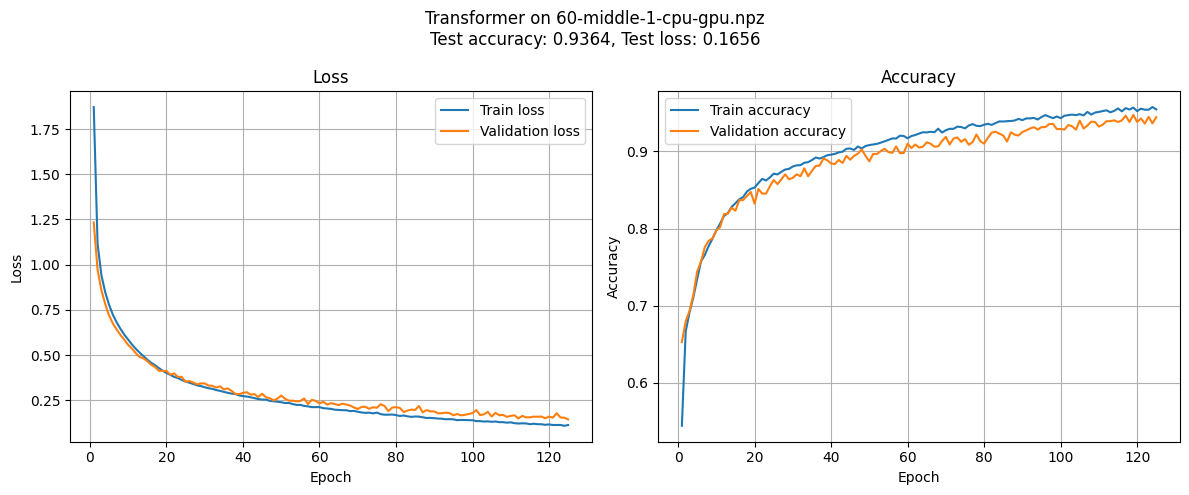

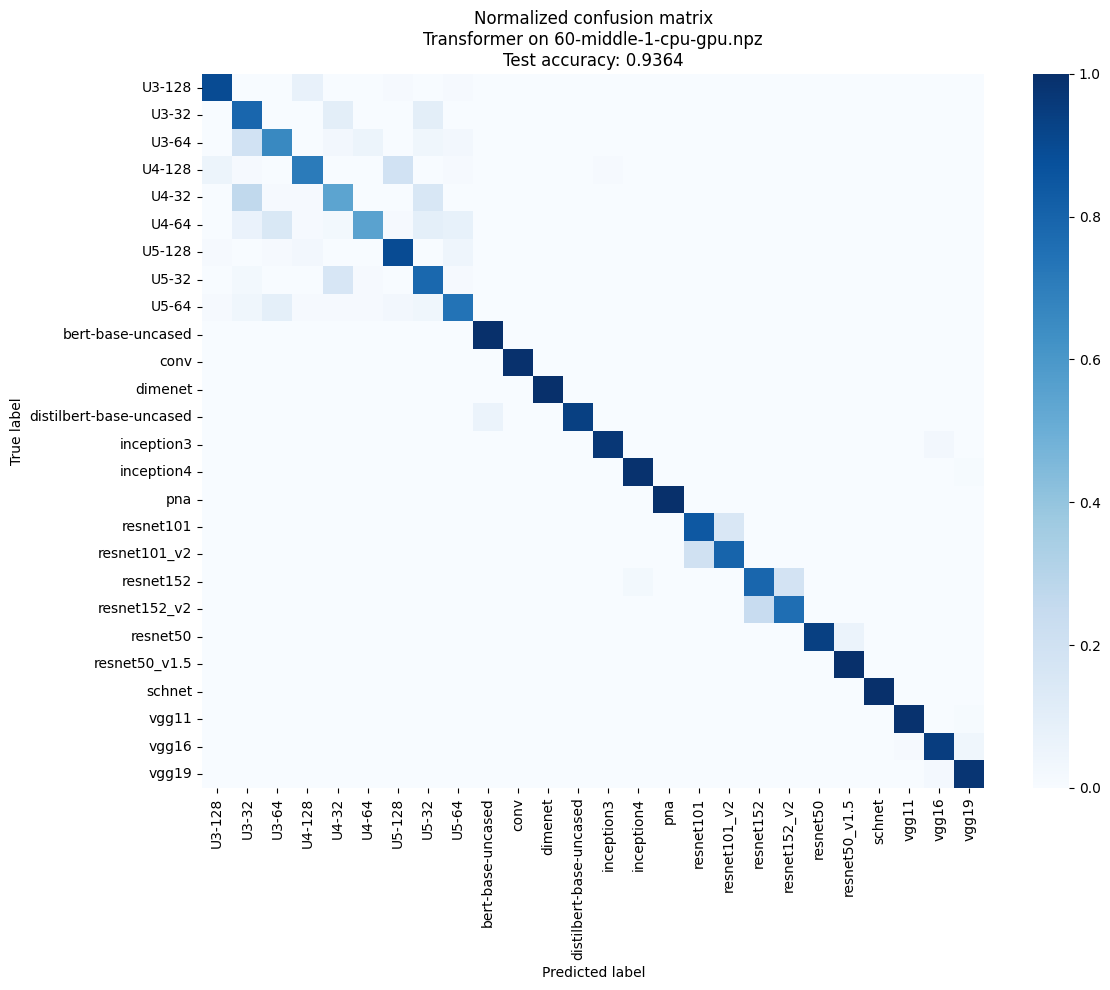

Worst run:
Model: Transformer
Dataset: 60-start-1-cpu-gpu.npz
Test accuracy: 0.8177083333333334
Test loss: 0.46854317828751446



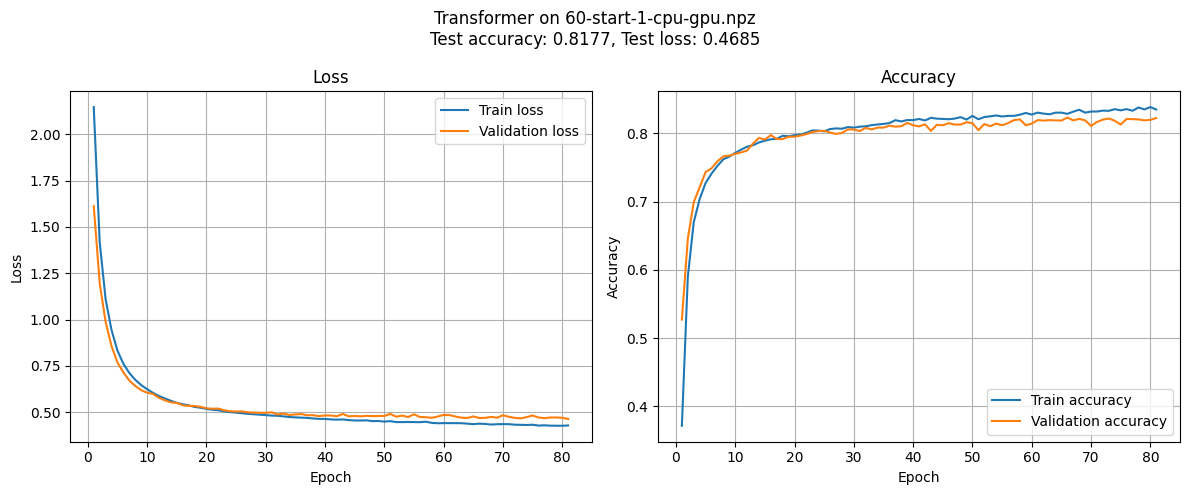

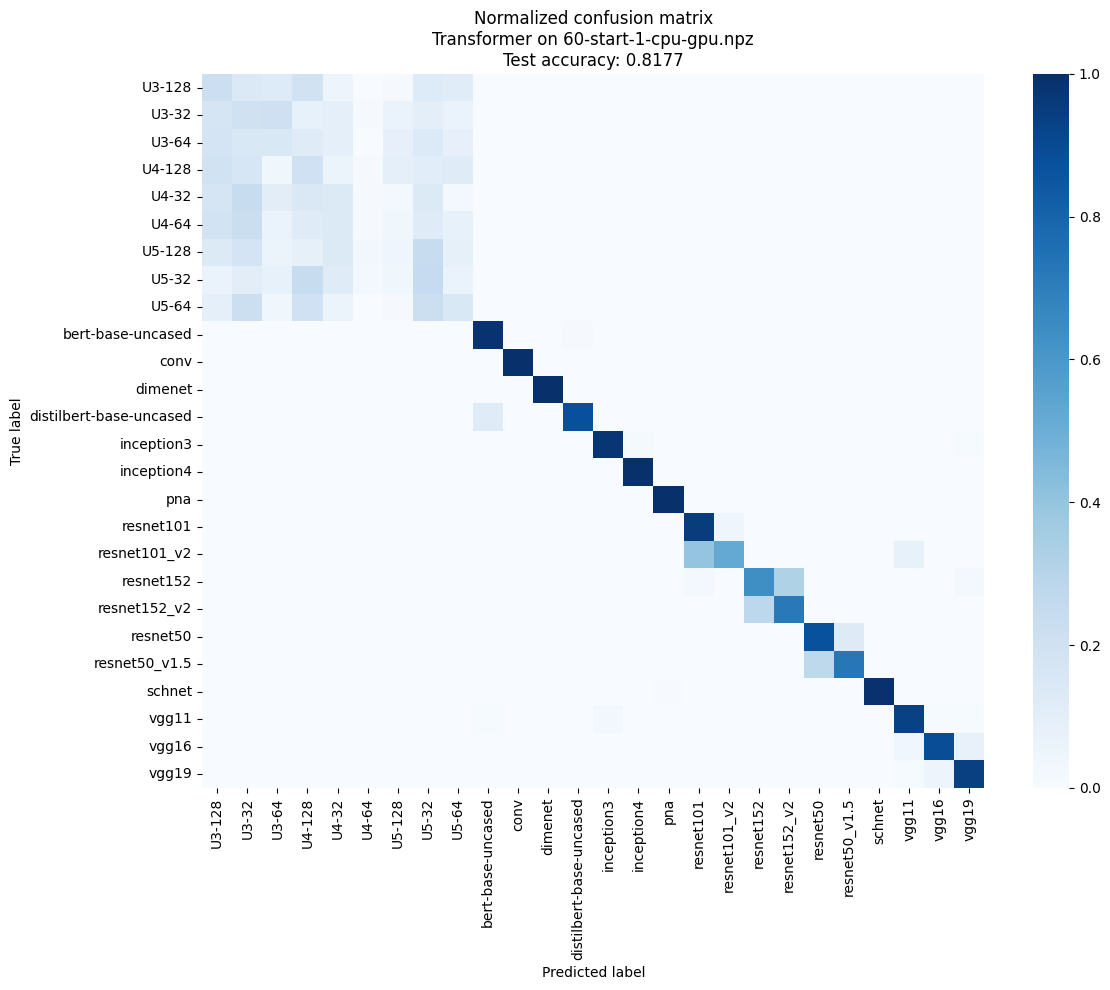

In [34]:
best_result, worst_result = plot_best_and_worst_runs(
    results_transformer,
    metric="test_acc",
    class_names=class_names_combined,
    normalize_cm=True,
)

### Two Tower Transformer

In [38]:
model = build_two_tower_model().to(device)

total_params, trainable_params = count_model_parameters(model)
total_params, trainable_params

(138330, 138330)

In [35]:
results_two_tower = main(
    dataset_ls=combined_datasets,
    model_builder=build_two_tower_model,
    model_name="TwoTowerTransformer",
    separate=False,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

Training TwoTowerTransformer on 60-start-1-cpu-gpu.npz


100%|██████████| 92/92 [00:01<00:00, 61.03it/s]


Epoch [1/125] | Time: 27.68s
Train Loss: 1.9693 | Train Accuracy: 0.4184
Val Loss:   1.3676 | Val Accuracy:   0.5737


100%|██████████| 92/92 [00:01<00:00, 60.28it/s]


Epoch [6/125] | Time: 27.67s
Train Loss: 0.6867 | Train Accuracy: 0.7552
Val Loss:   0.6608 | Val Accuracy:   0.7615


...

Epoch [116/125] | Time: 26.69s
Train Loss: 0.1319 | Train Accuracy: 0.9496
Val Loss:   0.2431 | Val Accuracy:   0.9190


100%|██████████| 89/89 [00:01<00:00, 61.08it/s]


Epoch [121/125] | Time: 26.69s
Train Loss: 0.1304 | Train Accuracy: 0.9513
Val Loss:   0.2420 | Val Accuracy:   0.9207
Early stopping on epoch 121
Best validation accuracy: 92.74%


100%|██████████| 111/111 [00:01<00:00, 60.76it/s]

Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Epoch_125/TwoTowerTransformer_60-random-5-cpu-gpu.pt
Test accuracy: 0.9326
--------------------------------------------------------------------------------


Best run:
Model: TwoTowerTransformer
Dataset: 60-random-4-cpu-gpu.npz
Test accuracy: 0.9399153737658674
Test loss: 0.15148323646973824



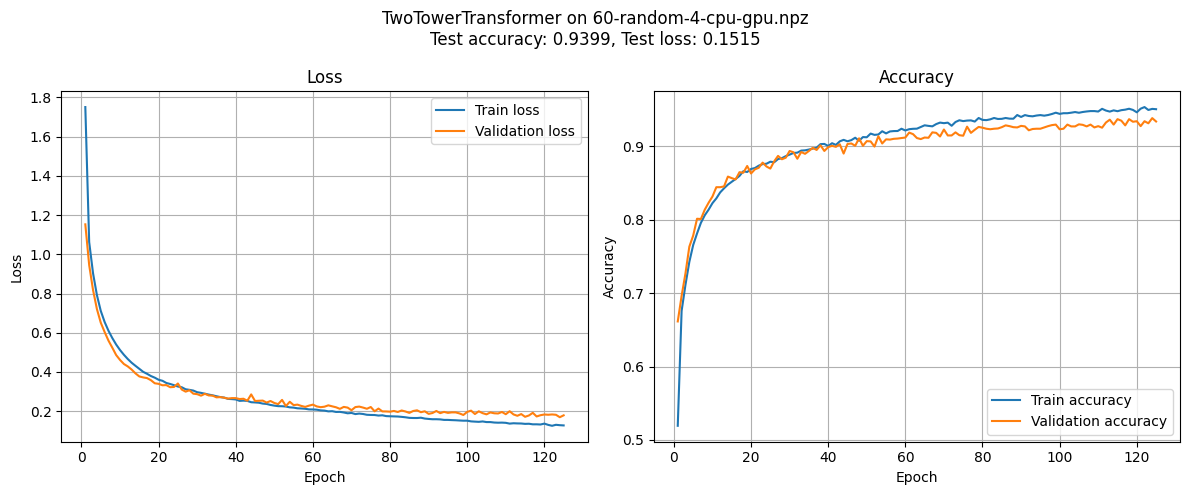

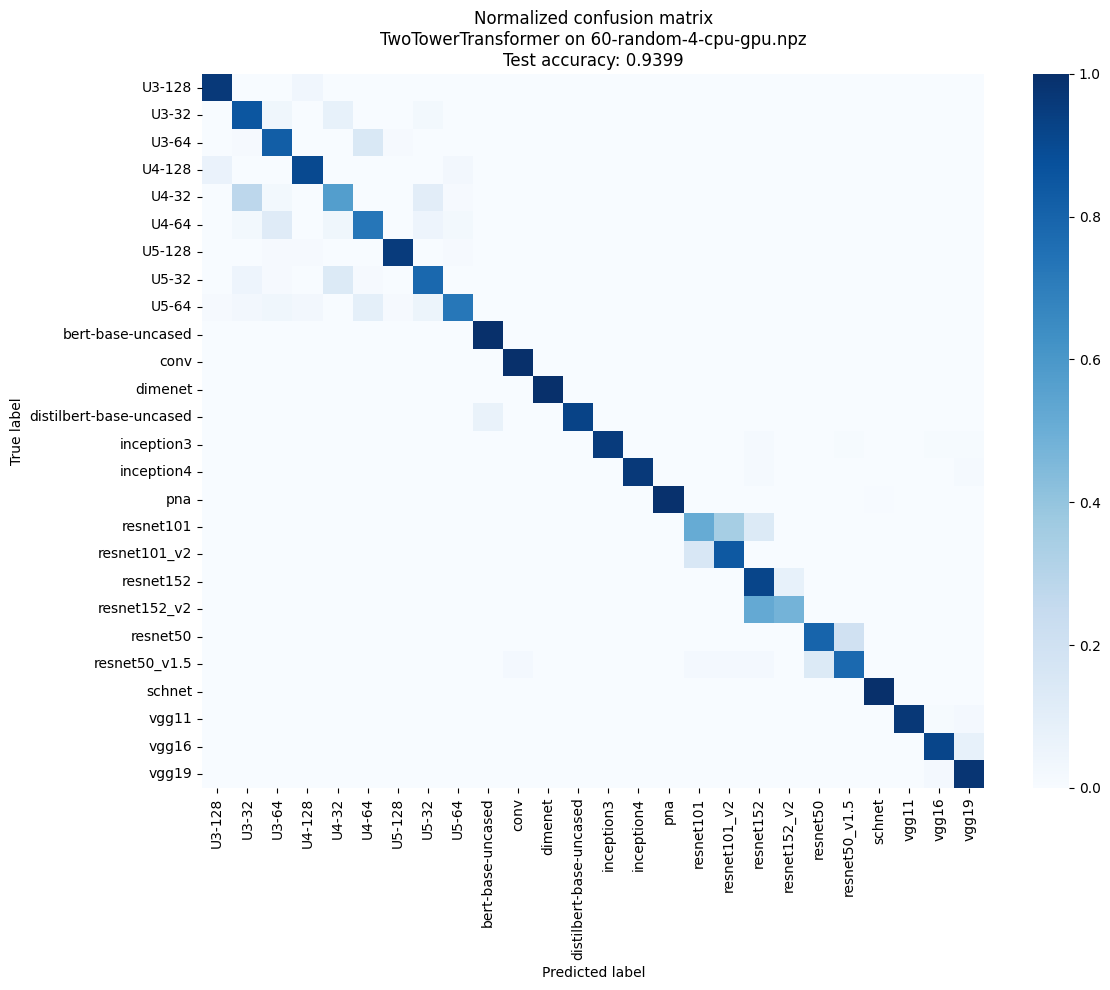

Worst run:
Model: TwoTowerTransformer
Dataset: 60-start-1-cpu-gpu.npz
Test accuracy: 0.8259320175438597
Test loss: 0.4781132886153564



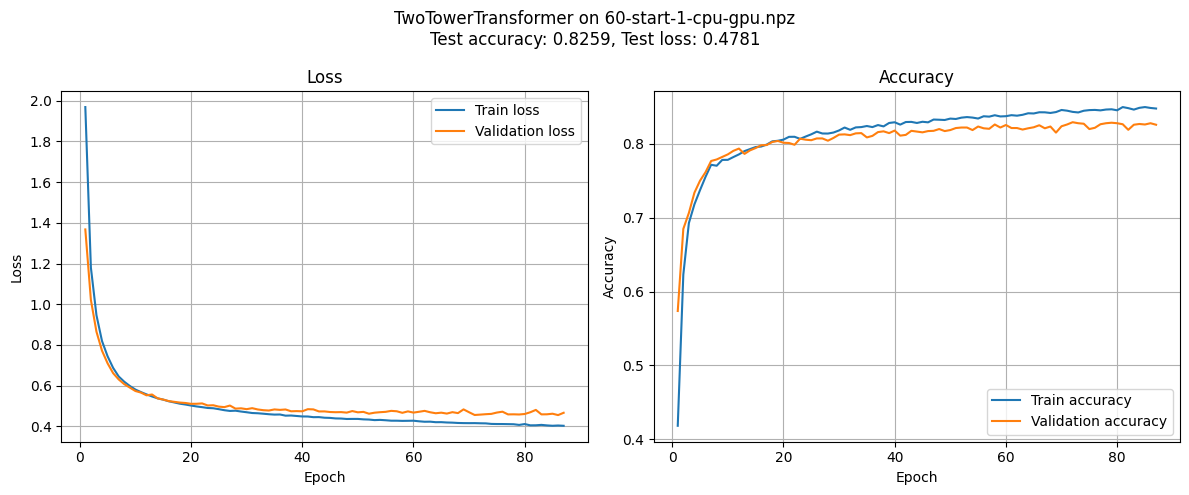

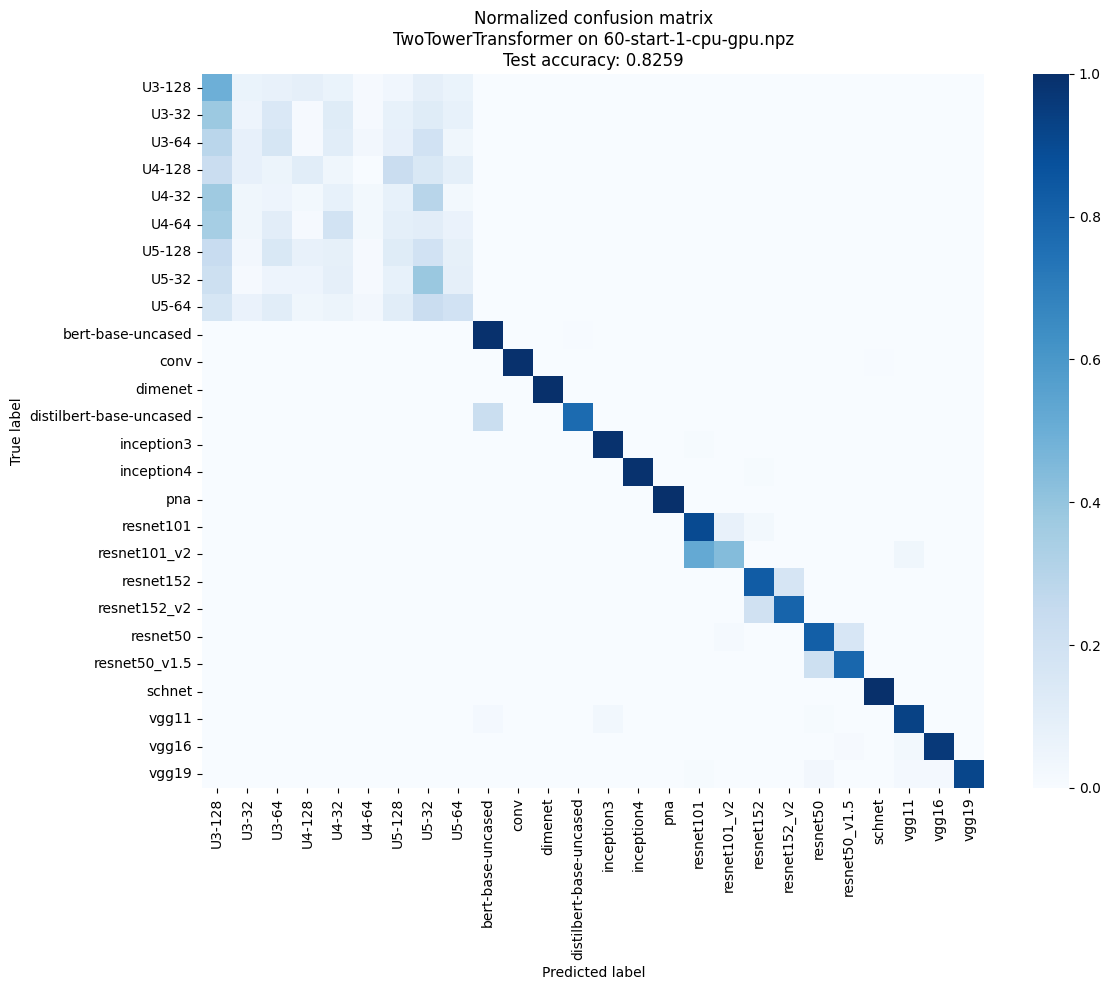

In [36]:
best_result, worst_result = plot_best_and_worst_runs(
    results_two_tower,
    metric="test_acc",
    class_names=class_names_combined,
    normalize_cm=True,
)

### Gated Two Tower Transformer

In [39]:
model = build_gated_two_tower_model().to(device)

total_params, trainable_params = count_model_parameters(model)
total_params, trainable_params

(144922, 144922)

In [32]:
results_gated = main(
    dataset_ls=separated_datasets,
    model_builder=build_gated_two_tower_model,
    model_name="GatedTwoTowerTransformer",
    separate=True,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

Training GatedTwoTowerTransformer on 60-start-1-separate-cpu-gpu.npz


100%|██████████| 92/92 [00:00<00:00, 124.94it/s]


Epoch [1/125] | Time: 13.05s
Train Loss: 2.0855 | Train Accuracy: 0.3933
Val Loss:   1.4917 | Val Accuracy:   0.5579


100%|██████████| 92/92 [00:00<00:00, 127.88it/s]


Epoch [6/125] | Time: 12.90s
Train Loss: 0.7336 | Train Accuracy: 0.7376
Val Loss:   0.6740 | Val Accuracy:   0.7560


...

Epoch [116/125] | Time: 13.53s
Train Loss: 0.1226 | Train Accuracy: 0.9525
Val Loss:   0.1967 | Val Accuracy:   0.9264


100%|██████████| 89/89 [00:00<00:00, 118.42it/s]


Epoch [121/125] | Time: 13.50s
Train Loss: 0.1153 | Train Accuracy: 0.9559
Val Loss:   0.2045 | Val Accuracy:   0.9271


100%|██████████| 111/111 [00:00<00:00, 118.30it/s]

Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Epoch_125/GatedTwoTowerTransformer_60-random-5-separate-cpu-gpu.pt
Test accuracy: 0.9352
--------------------------------------------------------------------------------


Best run:
Model: GatedTwoTowerTransformer
Dataset: 60-middle-1-separate-cpu-gpu.npz
Test accuracy: 0.9501969611705121
Test loss: 0.1323011656889648



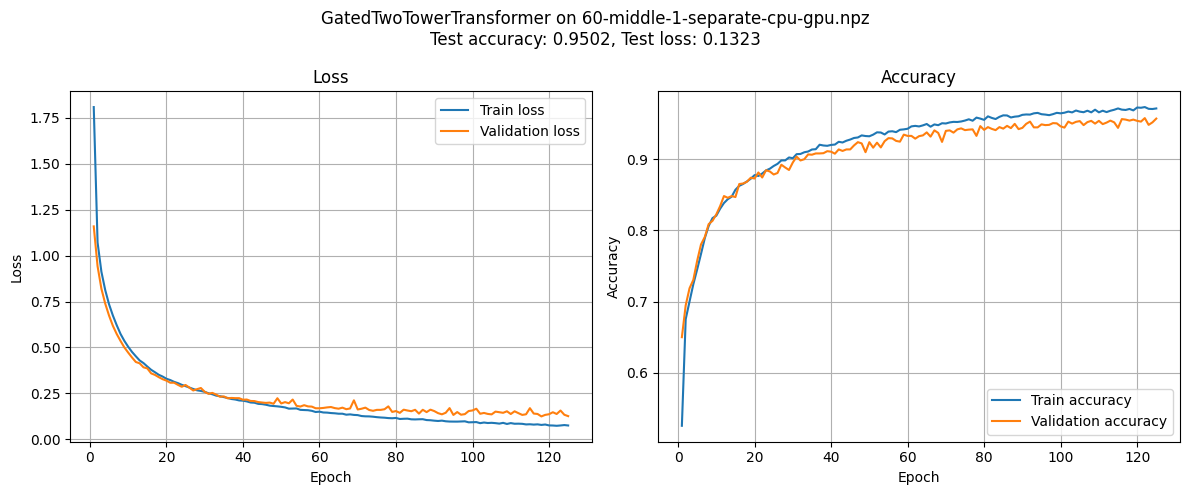

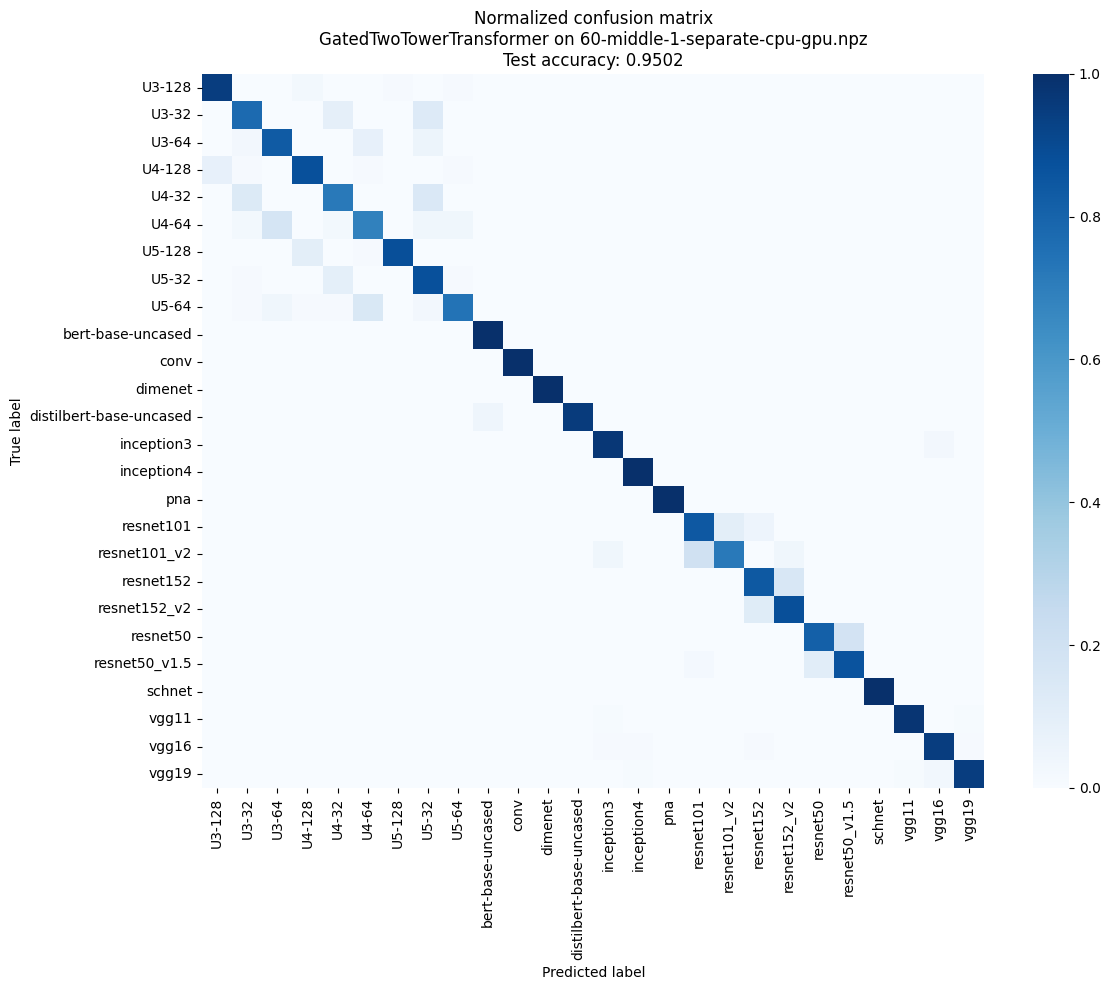

Worst run:
Model: GatedTwoTowerTransformer
Dataset: 60-start-1-separate-cpu-gpu.npz
Test accuracy: 0.8297697368421053
Test loss: 0.4530740952805469



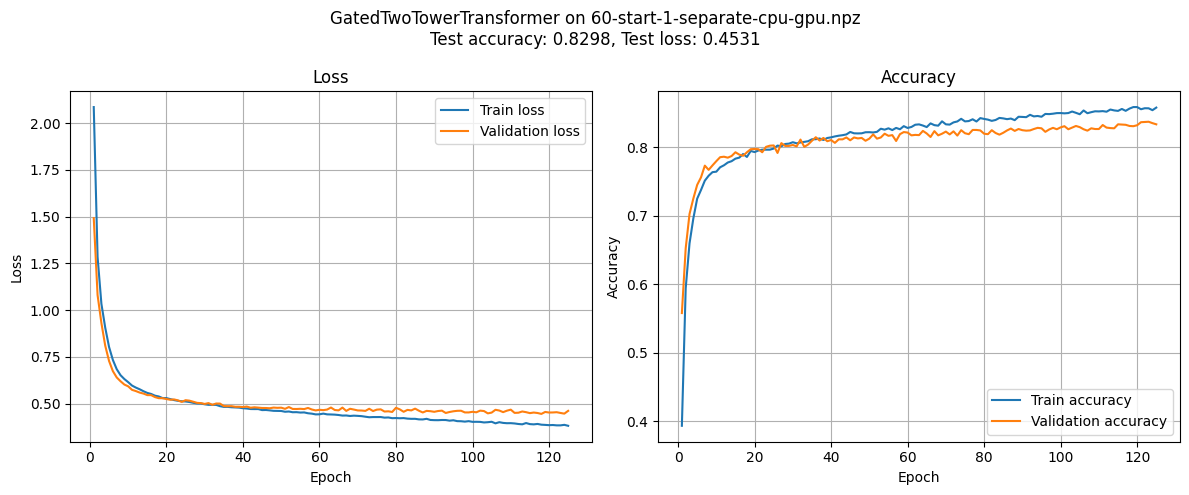

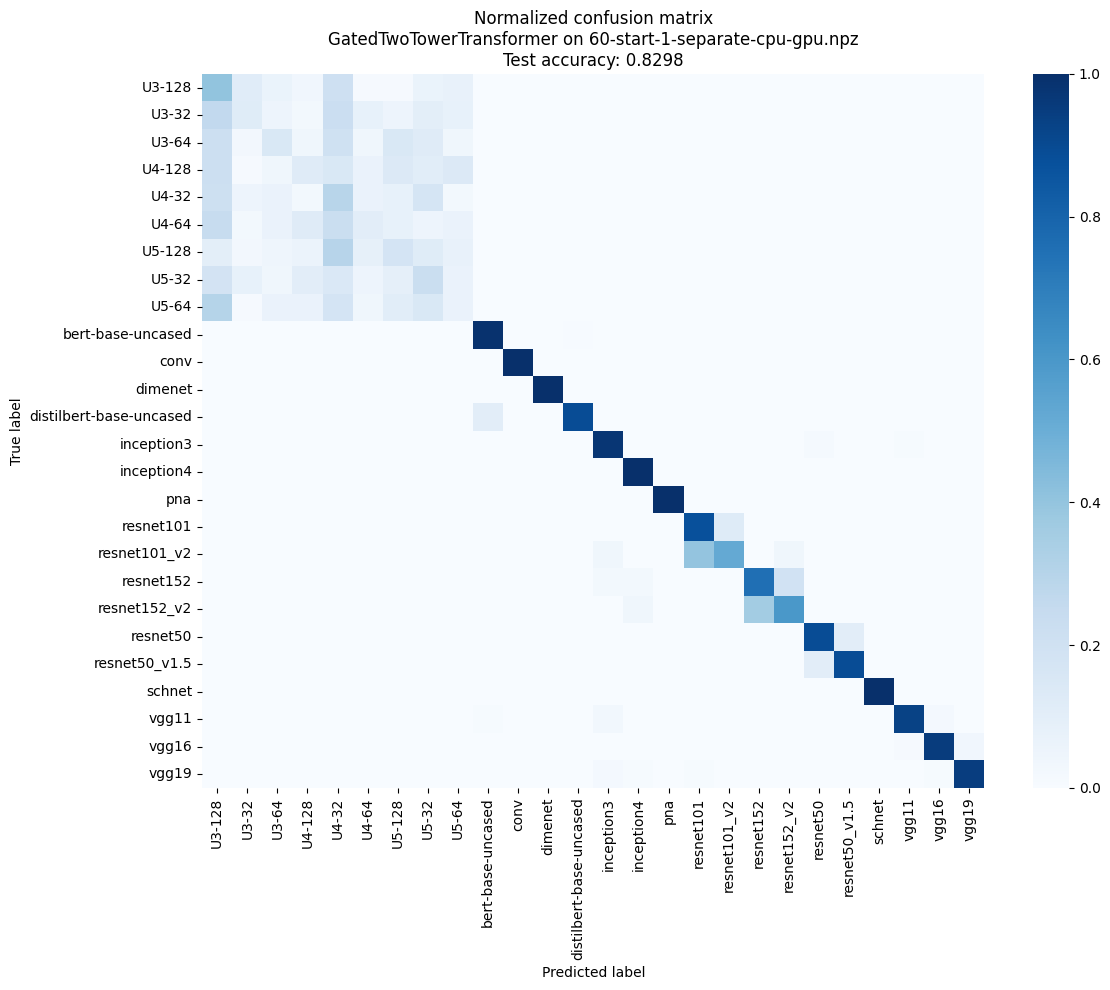

In [33]:
best_result, worst_result = plot_best_and_worst_runs(
    results_gated,
    metric="test_acc",
    class_names=class_names_separate,
    normalize_cm=True,
)

In [40]:
def load_model_from_path(model_builder, model_path, device):
    model = model_builder().to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

In [69]:
# for all saved models run on all datasets to get the test loss
saved_models_dir = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Epoch_125"
for _model in os.listdir(saved_models_dir):
  if _model.endswith(".pt"):
    model_name = _model.split("_")[0]
    dataset_name = _model.split("_")[1].split(".")[0]
    desired_dataset_idx = None
    if model_name == "Transformer":
      model = load_model_from_path(build_transformer_model, os.path.join(saved_models_dir, _model), device)
      for idx, _dataset in enumerate(combined_datasets):
        if _dataset["name"].split(".")[0] == dataset_name:
          desired_dataset_idx = idx
      desired_dataset= combined_datasets[desired_dataset_idx]
      test_loss, test_acc, test_labels, test_preds = evaluate(
          model=model,
          test_loader=desired_dataset["test_dl"],
          loss_fn=nn.CrossEntropyLoss(),
          separate=False,
      )
    elif model_name == "TwoTowerTransformer":
      model = load_model_from_path(build_two_tower_model, os.path.join(saved_models_dir, _model), device)
      for idx, _dataset in enumerate(combined_datasets):
        if _dataset["name"].split(".")[0] == dataset_name:
          desired_dataset_idx = idx
      desired_dataset= combined_datasets[desired_dataset_idx]
      test_loss, test_acc, test_labels, test_preds = evaluate(
          model=model,
          test_loader=desired_dataset["test_dl"],
          loss_fn=nn.CrossEntropyLoss(),
          separate=False,
      )
    else:
      model = load_model_from_path(build_gated_two_tower_model, os.path.join(saved_models_dir, _model), device)
      for idx, _dataset in enumerate(separated_datasets):
        if _dataset["name"].split(".")[0] == dataset_name:
          desired_dataset_idx = idx
      desired_dataset= separated_datasets[desired_dataset_idx]
      test_loss, test_acc, test_labels, test_preds = evaluate(
          model=model,
          test_loader=desired_dataset["test_dl"],
          loss_fn=nn.CrossEntropyLoss(),
          separate=True,
      )
    print(f"Model: {model_name}, Dataset: {dataset_name}, Test Loss: {test_loss}")



100%|██████████| 114/114 [00:01<00:00, 106.34it/s]


Model: Transformer, Dataset: 60-start-1-cpu-gpu, Test Loss: 0.46854317828751446


100%|██████████| 112/112 [00:00<00:00, 119.06it/s]


Model: Transformer, Dataset: 60-middle-1-cpu-gpu, Test Loss: 0.16558580142044926


100%|██████████| 111/111 [00:00<00:00, 118.14it/s]


...

Model: GatedTwoTowerTransformer, Dataset: 60-random-3-separate-cpu-gpu, Test Loss: 0.17379226553403146


100%|██████████| 111/111 [00:00<00:00, 113.32it/s]


Model: GatedTwoTowerTransformer, Dataset: 60-random-4-separate-cpu-gpu, Test Loss: 0.1389897314676613


100%|██████████| 111/111 [00:00<00:00, 114.65it/s]

Model: GatedTwoTowerTransformer, Dataset: 60-random-5-separate-cpu-gpu, Test Loss: 0.1605899332609518


In [71]:
results_to_dataframe(results_gated)

,model_name,dataset_name,test_acc,test_loss,best_val_acc,final_val_acc,final_train_acc,num_epochs_run
1,GatedTwoTowerTransformer,60-middle-1-separate-cpu-gpu.npz,0.950197,0.132301,0.957439,0.956736,0.970976,125
5,GatedTwoTowerTransformer,60-random-4-separate-cpu-gpu.npz,0.945839,0.138990,0.944640,0.938293,0.958653,125
4,GatedTwoTowerTransformer,60-random-3-separate-cpu-gpu.npz,0.942519,0.173792,0.942585,0.932723,0.956399,113
2,GatedTwoTowerTransformer,60-random-1-separate-cpu-gpu.npz,0.939086,0.179793,0.942192,0.940783,0.953636,99
6,GatedTwoTowerTransformer,60-random-5-separate-cpu-gpu.npz,0.935156,0.160590,0.933051,0.930585,0.955499,125
3,GatedTwoTowerTransformer,60-random-2-separate-cpu-gpu.npz,0.934838,0.181304,0.937236,0.937236,0.952662,125
0,GatedTwoTowerTransformer,60-start-1-separate-cpu-gpu.npz,0.829770,0.453074,0.837217,0.833448,0.857865,125


In [73]:
results_transformer = pd.read_csv("/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Results/Transformer_results_summary.csv")
results_two_tower = pd.read_csv("/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Results/TwoTowerTransformer_results_summary.csv")
results_gated = pd.read_csv("/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Results/GatedTwoTowerTransformer_results_summary.csv")

In [81]:
summary_df = pd.concat([results_transformer, results_two_tower, results_gated])

In [83]:
summary_df

,model_name,dataset_name,test_acc,test_loss,best_val_acc,final_val_acc,final_train_acc,num_epochs_run,total_params,trainable_params,training_duration_sec,training_duration_min,avg_epoch_time_sec,model_path
0,Transformer,60-start-1-cpu-gpu.npz,0.817700,0.468543,0.823200,0.822500,0.834900,81,69658,69658,1128.568235,18.809471,13.932941,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
1,Transformer,60-middle-1-cpu-gpu.npz,0.936400,0.165586,0.942700,0.942700,0.955400,125,69658,69658,1713.650000,28.560833,13.709200,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
2,Transformer,60-random-1-cpu-gpu.npz,0.918200,0.227930,0.925300,0.911900,0.940300,125,69658,69658,1714.550000,28.575833,13.716400,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
3,Transformer,60-random-2-cpu-gpu.npz,0.902100,0.251899,0.915000,0.912200,0.922400,90,69658,69658,1231.550000,20.525833,13.683889,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
4,Transformer,60-random-3-cpu-gpu.npz,0.914300,0.235912,0.913000,0.911200,0.926200,87,69658,69658,1191.175000,19.852917,13.691667,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
5,Transformer,60-random-4-cpu-gpu.npz,0.921600,0.213014,0.931900,0.920000,0.940100,110,69658,69658,1505.600000,25.093333,13.687273,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
6,Transformer,60-random-5-cpu-gpu.npz,0.929200,0.188454,0.926000,0.926000,0.945600,125,69658,69658,1704.400000,28.406667,13.635200,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
0,TwoTowerTransformer,60-start-1-cpu-gpu.npz,0.825900,0.478113,0.829000,0.827600,0.848300,87,138330,138330,2402.891667,40.048194,27.619444,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
1,TwoTowerTransformer,60-middle-1-cpu-gpu.npz,0.939200,0.161880,0.949300,0.939500,0.961800,125,138330,138330,3356.200000,55.936667,26.849600,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
2,TwoTowerTransformer,60-random-1-cpu-gpu.npz,0.934600,0.186188,0.939400,0.932300,0.952000,124,138330,138330,3319.083200,55.318053,26.766800,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...


In [86]:
summary_df.groupby("model_name").mean("test_acc").sort_values("test_acc", ascending=False)

,test_acc,test_loss,best_val_acc,final_val_acc,final_train_acc,num_epochs_run,total_params,trainable_params,training_duration_sec,training_duration_min,avg_epoch_time_sec
model_name,,,,,,,,,,,
GatedTwoTowerTransformer,0.925344,0.202835,0.927766,0.924258,0.943670,119.571429,144922.0,144922.0,1618.876752,26.981279,13.536724
TwoTowerTransformer,0.918786,0.222646,0.919229,0.912186,0.937129,116.571429,138330.0,138330.0,3134.714087,52.245235,26.920471
Transformer,0.905643,0.250191,0.911014,0.906643,0.923557,106.142857,69658.0,69658.0,1455.641891,24.260698,13.722367
